<a href="https://colab.research.google.com/github/Pradyumna-Shee/Snowflake-ELT-Dynamic_Tables-Streams_and_Tasks/blob/main/10_gold_layer_business_reports_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.primitives.asymmetric import rsa
import os

key_dir = os.path.expanduser("~/.snowflake_keys")
os.makedirs(key_dir, exist_ok=True)
key_path = os.path.join(key_dir, "sec_financial_pipeline_rsa_key.p8")

private_key = rsa.generate_private_key(public_exponent=65537, key_size=2048)
with open(key_path, "wb") as f:
    f.write(private_key.private_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PrivateFormat.PKCS8,
        encryption_algorithm=serialization.NoEncryption(),
    ))

public_pem = private_key.public_key().public_bytes(
    encoding=serialization.Encoding.PEM,
    format=serialization.PublicFormat.SubjectPublicKeyInfo,
).decode()
public_key_body = "".join(l for l in public_pem.splitlines() if "PUBLIC KEY" not in l)

print("Private key saved to:", key_path)
print()
print("Run in Snowsight:")
print(f"ALTER USER PRADYUMNASHEE SET RSA_PUBLIC_KEY='{public_key_body}';")

Private key saved to: /root/.snowflake_keys/sec_financial_pipeline_rsa_key.p8

Run in Snowsight:
ALTER USER PRADYUMNASHEE SET RSA_PUBLIC_KEY='MIIBIjANBgkqhkiG9w0BAQEFAAOCAQ8AMIIBCgKCAQEAsuVBLWaCvXlBhGDZG/8xxLyxG7cm/BUUW51eNcP76p2Zu+32JZWulkpSPc/zdbHm7eDVnccg57NME/D5TobDthS1VBZKhyqTPYeQ8KTE0vHfXYvoNx8BnkavaJnPZ63u21OH+HpbjLZOewhxLeRr9Qt3bWv/1M9eK/nBBXzaf7vPlHo4qKTMgz/2JTBccTOLQNwU5KAk6wnN1ZxSmjzddYt1PyvihE4dimcgth5NcXE9UWg806PzfLPv7QabWjGRjcPyIMwQWpkUa1zyXIkJ4nCpzTgM5wAqZ61G+GZDnvNSVfZMbkfWth5GhmeXesLqXB87DVtAjLS8FtD1GkIXbwIDAQAB';


In [ ]:
print(open('/root/.snowflake_keys/sec_financial_pipeline_rsa_key.p8').read())

In [ ]:
from cryptography.hazmat.primitives import serialization

with open('/root/.snowflake_keys/sec_financial_pipeline_rsa_key.p8', 'rb') as f:
    private_key = serialization.load_pem_private_key(f.read(), password=None)

public_pem = private_key.public_key().public_bytes(
    encoding=serialization.Encoding.PEM,
    format=serialization.PublicFormat.SubjectPublicKeyInfo,
).decode()

print("".join(l for l in public_pem.splitlines() if "PUBLIC KEY" not in l))

MIIBIjANBgkqhkiG9w0BAQEFAAOCAQ8AMIIBCgKCAQEAsuVBLWaCvXlBhGDZG/8xxLyxG7cm/BUUW51eNcP76p2Zu+32JZWulkpSPc/zdbHm7eDVnccg57NME/D5TobDthS1VBZKhyqTPYeQ8KTE0vHfXYvoNx8BnkavaJnPZ63u21OH+HpbjLZOewhxLeRr9Qt3bWv/1M9eK/nBBXzaf7vPlHo4qKTMgz/2JTBccTOLQNwU5KAk6wnN1ZxSmjzddYt1PyvihE4dimcgth5NcXE9UWg806PzfLPv7QabWjGRjcPyIMwQWpkUa1zyXIkJ4nCpzTgM5wAqZ61G+GZDnvNSVfZMbkfWth5GhmeXesLqXB87DVtAjLS8FtD1GkIXbwIDAQAB


# New Section

In [ ]:
!pip install snowflake-connector-python -q

from google.colab import userdata
from cryptography.hazmat.primitives import serialization
import snowflake.connector

# Read private key stored securely in Colab
private_key = serialization.load_pem_private_key(
    userdata.get("SNOWFLAKE_PRIVATE_KEY").encode(),
    password=None
)

# Convert key to the format required by Snowflake
private_key = private_key.private_bytes(
    encoding=serialization.Encoding.DER,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption()
)

# Connect to Snowflake
conn = snowflake.connector.connect(
    account="MKBNBME-UB36734",
    user="PRADYUMNASHEE",
    private_key=private_key,
    role="SEC_ANALYST_ROLE",
    warehouse="SEC_FINANCIAL_DATA_PIPELINE_WAREHOUSE",
    database="SEC_FINANCIAL_DATA",
    schema="GOLD_SEC_ANALYTICS_REPORTING"
)

cur = conn.cursor()

print(cur.execute("SELECT CURRENT_USER(), CURRENT_ROLE(), CURRENT_WAREHOUSE()").fetchone())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.0/100.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.5 MB/s eta 0:00:00
('PRADYUMNASHEE', 'SEC_ANALYST_ROLE', 'SEC_FINANCIAL_DATA_PIPELINE_WAREHOUSE')


In [ ]:
cur.execute("""
    SELECT
        SUM(COMPANY_COUNT) AS TOTAL_COMPANIES,
        SUM(TOTAL_REVENUE_USD) AS TOTAL_REVENUE_USD,
        SUM(TOTAL_NET_INCOME_USD) AS TOTAL_NET_INCOME_USD,
        ROUND(100 * SUM(TOTAL_NET_INCOME_USD) / NULLIF(SUM(TOTAL_REVENUE_USD), 0), 2) AS AGGREGATE_MARGIN_PERCENT
    FROM REPORT_INDUSTRY_PROFITABILITY
    WHERE CALENDAR_YEAR_QUARTER = (SELECT MAX(CALENDAR_YEAR_QUARTER) FROM REPORT_INDUSTRY_PROFITABILITY)
""")
companies, revenue, net_income, margin = cur.fetchone()

print(f"Companies reporting:   {companies:,}")
print(f"Total revenue:         ${revenue:,.0f}")
print(f"Total net income:      ${net_income:,.0f}")
print(f"Aggregate margin:      {margin}%")

Companies reporting:   157
Total revenue:         $608,816,536,835
Total net income:      $64,163,644,255
Aggregate margin:      10.54%


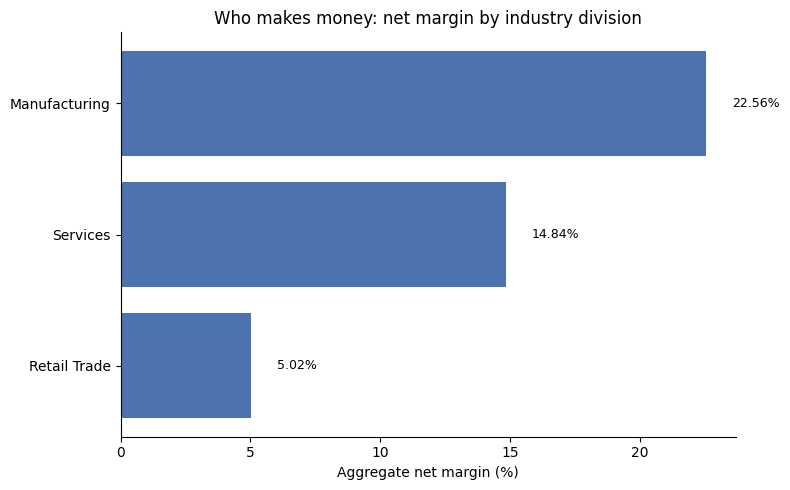

In [ ]:
import matplotlib.pyplot as plt

cur.execute("""
    SELECT INDUSTRY_DIVISION, AGGREGATE_MARGIN_PERCENT
    FROM REPORT_INDUSTRY_PROFITABILITY
    WHERE CALENDAR_YEAR_QUARTER = (SELECT MAX(CALENDAR_YEAR_QUARTER) FROM REPORT_INDUSTRY_PROFITABILITY)
    ORDER BY AGGREGATE_MARGIN_PERCENT DESC
""")
rows = cur.fetchall()
divisions = [r[0] for r in rows]
margins = [r[1] for r in rows]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(divisions, margins, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Aggregate net margin (%)")
ax.set_title("Who makes money: net margin by industry division")
for bar, value in zip(bars, margins):
    ax.text(bar.get_width() + (1 if value >= 0 else -1), bar.get_y() + bar.get_height()/2,
             f"{value}%", va="center", ha="left" if value >= 0 else "right", fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

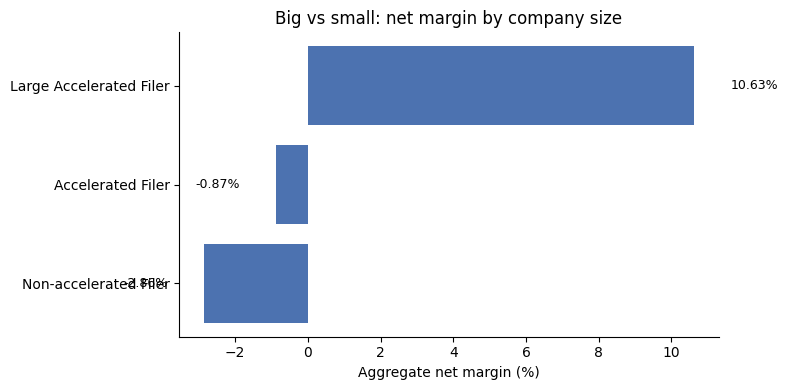

In [ ]:
cur.execute("""
    SELECT FILER_SIZE_NAME, AGGREGATE_MARGIN_PERCENT
    FROM REPORT_FILER_SIZE_PROFITABILITY
    WHERE CALENDAR_YEAR_QUARTER = (SELECT MAX(CALENDAR_YEAR_QUARTER) FROM REPORT_FILER_SIZE_PROFITABILITY)
    ORDER BY AGGREGATE_MARGIN_PERCENT DESC
""")
rows = cur.fetchall()
sizes = [r[0] for r in rows]
margins = [r[1] for r in rows]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(sizes, margins, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Aggregate net margin (%)")
ax.set_title("Big vs small: net margin by company size")
for bar, value in zip(bars, margins):
    ax.text(bar.get_width() + (1 if value >= 0 else -1), bar.get_y() + bar.get_height()/2,
             f"{value}%", va="center", ha="left" if value >= 0 else "right", fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

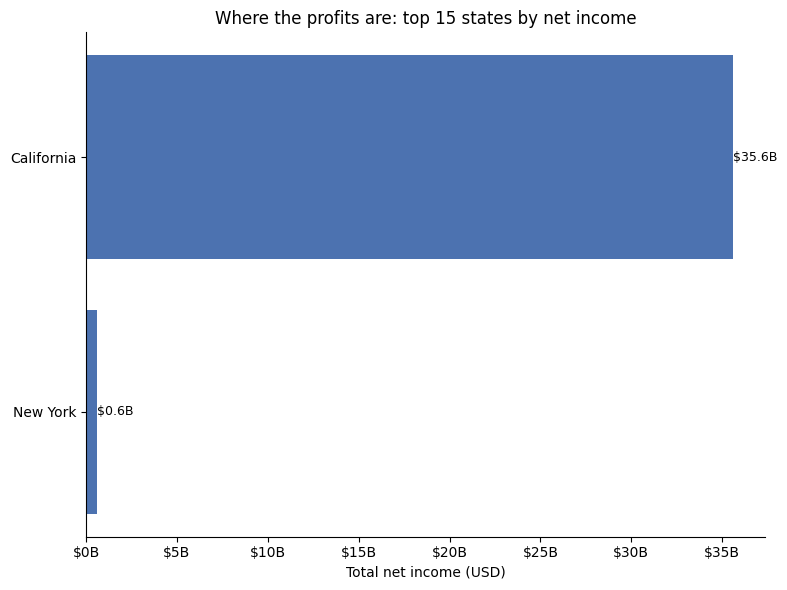

In [ ]:
cur.execute("""
    SELECT BUSINESS_STATE_NAME, TOTAL_NET_INCOME_USD
    FROM REPORT_STATE_PROFITABILITY
    WHERE CALENDAR_YEAR_QUARTER = (SELECT MAX(CALENDAR_YEAR_QUARTER) FROM REPORT_STATE_PROFITABILITY)
    ORDER BY TOTAL_NET_INCOME_USD DESC
    LIMIT 15
""")
rows = cur.fetchall()
states = [r[0] for r in rows]
net_income = [float(r[1]) for r in rows]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(states, net_income, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Total net income (USD)")
ax.set_title("Where the profits are: top 15 states by net income")
ax.xaxis.set_major_formatter(lambda x, pos: f"${x/1e9:.0f}B")
for bar, value in zip(bars, net_income):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f"${value/1e9:.1f}B", va="center", ha="left", fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
cur.close()
conn.close()